In [1]:
import pandas as pd

# Step 1: Define the item IDs we care about (example)
vital_ids = [220045, 220179, 220210]  # Heart Rate, SBP, MAP (you can change later)

# Step 2: Create empty list to collect chunks
chunks = []
chunk_size = 1000000  # 1 million rows at a time

# Step 3: Read in chunks and filter
for chunk in pd.read_csv("/Users/sahilbidya/Downloads/mimic-iv-3.1/icu/chartevents.csv",
                         usecols=['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid', 'valuenum'],
                         dtype={'subject_id': 'int32', 'hadm_id': 'int32', 'stay_id': 'int32', 'itemid': 'int32', 'valuenum': 'float32'},
                         chunksize=chunk_size):
    
    filtered_chunk = chunk[chunk['itemid'].isin(vital_ids)]
    chunks.append(filtered_chunk)
    
    if len(pd.concat(chunks)) > 500000:  # Optional: stop after 500k rows
        break

# Step 4: Combine chunks
chartevents_filtered = pd.concat(chunks)

# Step 5: Display
print("✅ Filtered data shape:", chartevents_filtered.shape)
chartevents_filtered.head()


✅ Filtered data shape: (527017, 6)


,subject_id,hadm_id,stay_id,charttime,itemid,valuenum
7,10000032,29079034,39553978,2180-07-23 14:11:00,220179,84.0
10,10000032,29079034,39553978,2180-07-23 14:12:00,220045,91.0
11,10000032,29079034,39553978,2180-07-23 14:12:00,220210,24.0
94,10000032,29079034,39553978,2180-07-23 14:30:00,220045,93.0
96,10000032,29079034,39553978,2180-07-23 14:30:00,220179,95.0


In [2]:
# Step 1: Create a pivot-friendly name for each itemid
vital_map = {
    220045: 'heart_rate',
    220179: 'systolic_bp',
    220210: 'map'
}
chartevents_filtered['vital_type'] = chartevents_filtered['itemid'].map(vital_map)

# Step 2: Convert to datetime
chartevents_filtered['charttime'] = pd.to_datetime(chartevents_filtered['charttime'])

# Step 3: Keep only necessary
vitals = chartevents_filtered[['subject_id', 'stay_id', 'charttime', 'vital_type', 'valuenum']].dropna()

# Step 4: Pivot to reshape (mean values per stay_id)
pivot_vitals = vitals.pivot_table(
    index='stay_id',
    columns='vital_type',
    values='valuenum',
    aggfunc='mean'
).reset_index()

# Step 5: Preview
print("✅ Engineered features per ICU stay:")
pivot_vitals.head()


✅ Engineered features per ICU stay:


vital_type,stay_id,heart_rate,map,systolic_bp
0,30002925,72.052635,20.894737,108.705879
1,30006506,64.428574,15.857142,155.615387
2,30008792,93.461540,22.367348,106.251747
3,30015770,73.158730,17.138212,119.960320
4,30020739,69.207550,17.415094,115.413795


In [3]:
# Create a simple binary label for cardiac arrest risk (proxy condition)
pivot_vitals['cardiac_arrest'] = (
    (pivot_vitals['map'] < 20) |
    (pivot_vitals['heart_rate'] > 130)
).astype(int)

# Check class balance
print("✅ Cardiac Arrest Label Distribution:")
print(pivot_vitals['cardiac_arrest'].value_counts())

# Final dataset ready
pivot_vitals.head()


✅ Cardiac Arrest Label Distribution:
cardiac_arrest
1    1371
0     792
Name: count, dtype: int64


vital_type,stay_id,heart_rate,map,systolic_bp,cardiac_arrest
0,30002925,72.052635,20.894737,108.705879,0
1,30006506,64.428574,15.857142,155.615387,1
2,30008792,93.461540,22.367348,106.251747,0
3,30015770,73.158730,17.138212,119.960320,1
4,30020739,69.207550,17.415094,115.413795,1


✅ Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       158
           1       1.00      1.00      1.00       275

    accuracy                           1.00       433
   macro avg       1.00      1.00      1.00       433
weighted avg       1.00      1.00      1.00       433



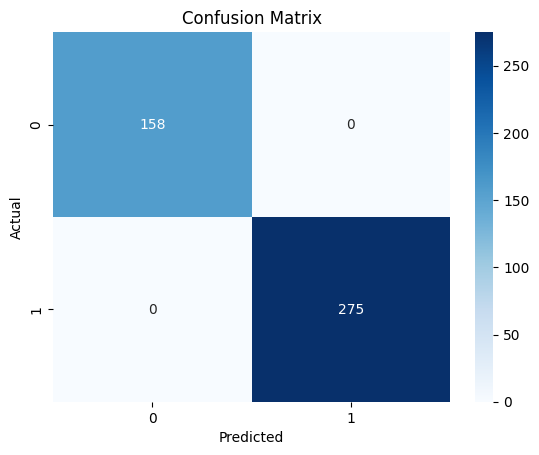

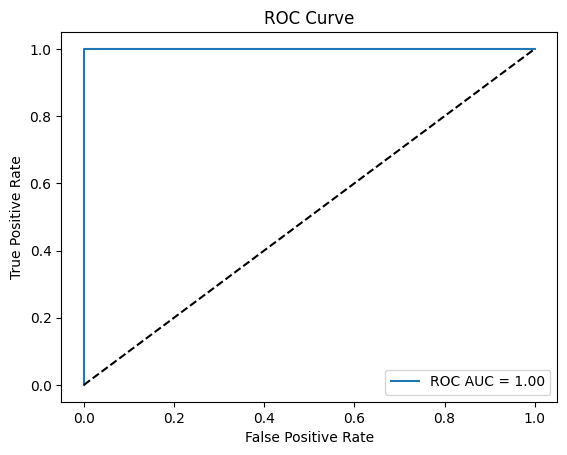

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Define X and y
features = ['heart_rate', 'map', 'systolic_bp']
X = pivot_vitals[features].fillna(0)
y = pivot_vitals['cardiac_arrest']

# Step 2: Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 4: Predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Step 5: Evaluation
print("✅ Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, y_proba):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


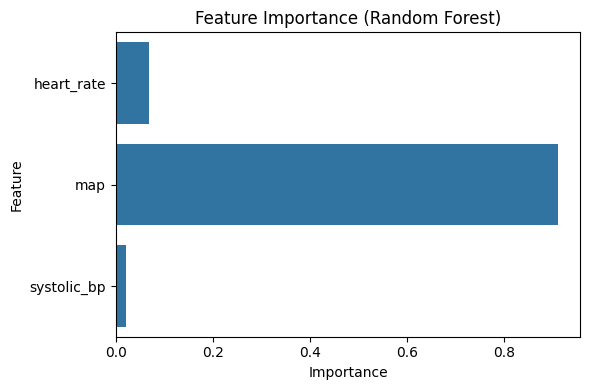

In [5]:
# Plot feature importance from Random Forest
importances = rf.feature_importances_
feature_names = features

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


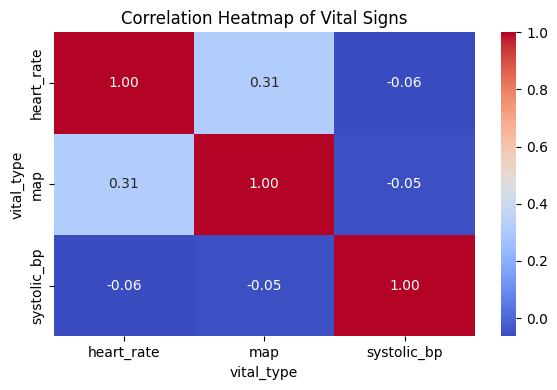

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a DataFrame with vital signs
# Using pivot_vitals as the cleaned ICU vitals table
# It includes: heart_rate, map, systolic_bp

plt.figure(figsize=(6, 4))
correlation = pivot_vitals[['heart_rate', 'map', 'systolic_bp']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Vital Signs")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()


/var/folders/1p/hh5dwk3j1vv96kn9c4gfnmmr0000gn/T/ipykernel_99219/3316941413.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pivot_vitals, x='cardiac_arrest', y=feature, palette='Set2')


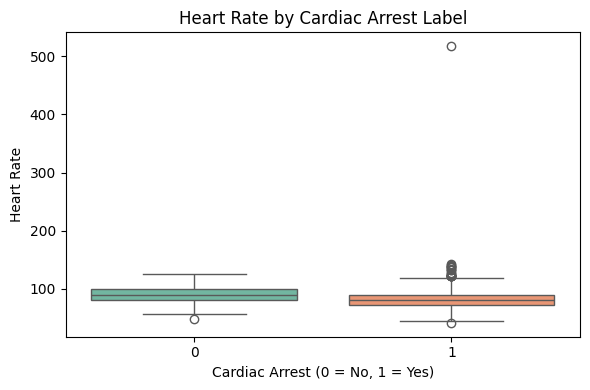

/var/folders/1p/hh5dwk3j1vv96kn9c4gfnmmr0000gn/T/ipykernel_99219/3316941413.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pivot_vitals, x='cardiac_arrest', y=feature, palette='Set2')


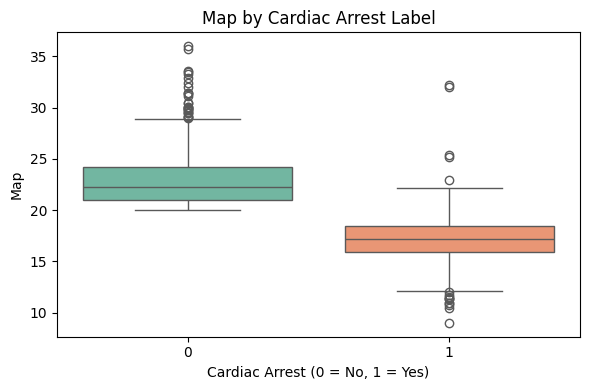

/var/folders/1p/hh5dwk3j1vv96kn9c4gfnmmr0000gn/T/ipykernel_99219/3316941413.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pivot_vitals, x='cardiac_arrest', y=feature, palette='Set2')


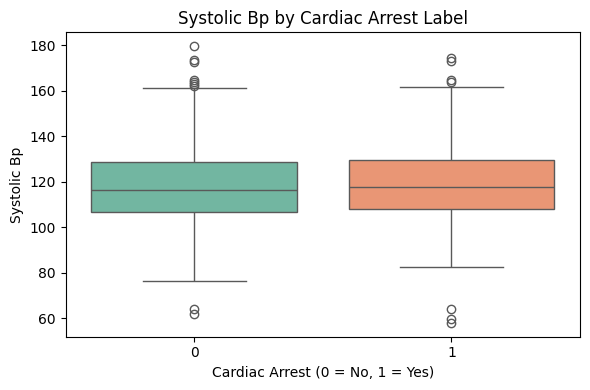

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# For each feature, create a separate boxplot by label (cardiac_arrest)
features = ['heart_rate', 'map', 'systolic_bp']

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=pivot_vitals, x='cardiac_arrest', y=feature, palette='Set2')
    plt.title(f'{feature.replace("_", " ").title()} by Cardiac Arrest Label')
    plt.xlabel("Cardiac Arrest (0 = No, 1 = Yes)")
    plt.ylabel(feature.replace("_", " ").title())
    plt.tight_layout()
    plt.savefig(f'{feature}_boxplot.png', dpi=300)
    plt.show()


In [8]:
import joblib

# Assuming 'rf' is your trained RandomForest model
joblib.dump(rf, "random_forest_model.pkl")


['random_forest_model.pkl']

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Train logistic regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 2. Predict
y_pred_log = log_reg.predict(X_test)

# 3. Classification report
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.99      0.97      0.98       158
           1       0.99      1.00      0.99       275

    accuracy                           0.99       433
   macro avg       0.99      0.99      0.99       433
weighted avg       0.99      0.99      0.99       433



/Users/sahilbidya/Developing World /PYHTON Basics/venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sahilbidya/Developing World /PYHTON Basics/venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sahilbidya/Developing World /PYHTON Basics/venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sahilbidya/Developing World /PYHTON Basics/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sahilbidya/Developing World /PYHTON Basics/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul

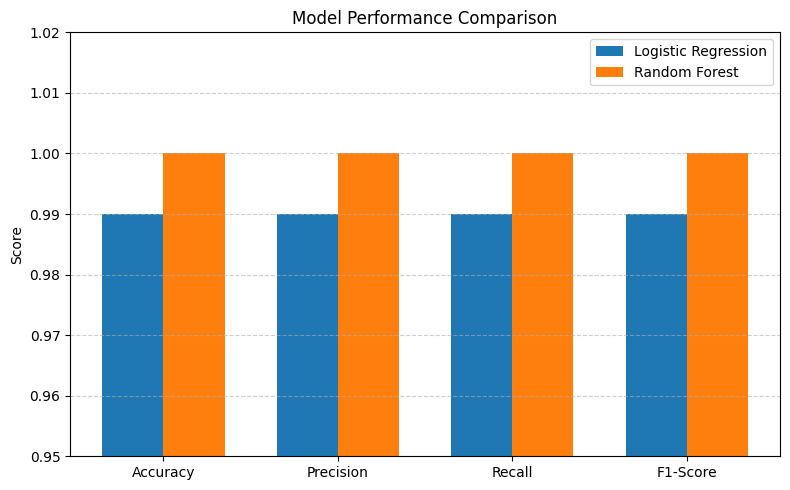

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Metric names
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Scores for each model
# Replace with your actual values if needed
logistic_scores = [0.99, 0.99, 0.99, 0.99]
rf_scores = [1.00, 1.00, 1.00, 1.00]

# Bar width and x-coordinates
bar_width = 0.35
x = np.arange(len(metrics))

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(x - bar_width/2, logistic_scores, bar_width, label='Logistic Regression')
plt.bar(x + bar_width/2, rf_scores, bar_width, label='Random Forest')

# Labels and formatting
plt.ylabel('Score')
plt.ylim(0.95, 1.02)
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
